# B0 -> D- pi+ on the 24c4 tuples

The D pi fit moved onto the 24c4 block7 and block8 samples. Unlike the 24c2 files these do
need the s24c4 run selection, so the lumi cut is switched on and the run ranges come from
the scan in the previous notebook.


In [ ]:
import os
import time
import math
import numpy as np
import uproot
import matplotlib.pyplot as plt
import ROOT
from ROOT import RooFit as RF
from IPython.display import Image as IPyImage, display as ipydisplay

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

ROOT.gROOT.SetBatch(True)
ROOT.EnableImplicitMT()

base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs loaded:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))

TREE_PATH = "Tuple/DecayTree"

FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_down_final_block7.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_up_final_block8.root",
]
assert all(os.path.exists(f) for f in FILES), "One or more FILES do not exist."


## Data

One file per polarity, block7 down and block8 up.


In [1]:
chain = ROOT.TChain(TREE_PATH)
for f in FILES:
    chain.Add(f)

print("Added files:", chain.GetListOfFiles().GetEntries())
print("Total entries in chain:", chain.GetEntries())


Welcome to JupyROOT 6.30/02
Added files: 2
Total entries in chain: 3136780



In [3]:
chain = ROOT.TChain(TREE_PATH)
for f in FILES:
    chain.Add(f)

print("Added files:", chain.GetListOfFiles().GetEntries())
print("Total entries in chain:", chain.GetEntries())

# a tree has to be open before its structure can be read
if chain.GetEntries() == 0:
    raise RuntimeError("Chain has no entries — cannot list branches.")
chain.LoadTree(0)
tree = chain.GetTree()
if not tree:
    raise RuntimeError("Failed to access underlying TTree from TChain.")

branches = tree.GetListOfBranches()
print("Number of branches:", branches.GetEntries())

def leaf_type(leaf):
    t = leaf.GetTypeName()
    if t: 
        return t
    # fall back to the title when the type is not exposed
    return leaf.GetTitle().split("/")[-1] if "/" in leaf.GetTitle() else "?"

# branch -> leaves, with types
for b in branches:
    bname = b.GetName()
    bcls  = b.GetClassName()  # non-empty for object branches
    leaves = b.GetListOfLeaves()
    if bcls:
        # TLorentzVector, std::vector<double> and similar
        print(f"• {bname}  (class: {bcls})")
    elif leaves and leaves.GetEntries() == 1:
        lf = leaves.At(0)
        print(f"• {bname}  [{leaf_type(lf)}]")
    else:
        print(f"• {bname}")
        for lf in leaves:
            print(f"    └─ {lf.GetName()}  [{leaf_type(lf)}]")

# aliases, where the tree defines any
aliases = tree.GetListOfAliases()
if aliases and aliases.GetEntries() > 0:
    print("\nAliases:")
    for a in aliases:
        print(f"• {a.GetName()} = {tree.GetAlias(a.GetName())}")


Added files: 2
Total entries in chain: 3136780
Number of branches: 291
• EVENTNUMBER  [ULong64_t]
• Hlt1TrackMVADecision  [Bool_t]
• Hlt1TwoTrackMVADecision  [Bool_t]
• Hlt1_TCK  [UInt_t]
• Hlt2B2OC_BdToDmPi_DmToPimPimKpDecision  [Bool_t]
• Hlt2Topo2BodyDecision  [Bool_t]
• Hlt2Topo3BodyDecision  [Bool_t]
• Hlt2_TCK  [UInt_t]
• RUNNUMBER  [UInt_t]
• lab0_BPVCHI2DOF  [Double_t]
• lab0_BPVDIRA  [Float_t]
• lab0_BPVFD  [Float_t]
• lab0_BPVFDCHI2  [Float_t]
• lab0_BPVIP  [Float_t]
• lab0_BPVIPCHI2  [Float_t]
• lab0_BPVLTIME  [Float_t]
• lab0_BPVX  [Float_t]
• lab0_BPVY  [Float_t]
• lab0_BPVZ  [Float_t]
• lab0_CHI2DOF  [Double_t]
• lab0_CHILD1_FDCHI2wrtSV  [Float_t]
• lab0_CHILD1_FDwrtSV  [Float_t]
• lab0_CHILD1_IPCHI2wrtSV  [Float_t]
• lab0_CHILD1_IPwrtSV  [Float_t]
• lab0_DTF_LifetimeFit_CHI2DOF  [Double_t]
• lab0_DTF_LifetimeFit_CTAU  [Double_t]
• lab0_DTF_LifetimeFit_CTAUERR  [Double_t]
• lab0_DTF_LifetimeFit_MASS  [Double_t]
• lab0_DTF_MassFitConsD_CHI2DOF  [Double_t]
• lab0_DTF_MassFi

In [14]:
chain.Show(0)        # print first entry
print(chain.GetListOfBranches().Print())


None
======> EVENT:0
 EVENTNUMBER     = 3878081693
 Hlt1TrackMVADecision = 1
 Hlt1TwoTrackMVADecision = 1
 Hlt1_TCK        = 268439690
 Hlt2B2OC_BdToDmPi_DmToPimPimKpDecision = 1
 Hlt2Topo2BodyDecision = 0
 Hlt2Topo3BodyDecision = 0
 Hlt2_TCK        = 3001333814
 RUNNUMBER       = 307710
 lab0_BPVCHI2DOF = 0.500316
 lab0_BPVDIRA    = 1
 lab0_BPVFD      = 11.9554
 lab0_BPVFDCHI2  = 4175.84
 lab0_BPVIP      = 0.00286934
 lab0_BPVIPCHI2  = 0.0449828
 lab0_BPVLTIME   = 0.00322817
 lab0_BPVX       = 0.437
 lab0_BPVY       = 0.0547
 lab0_BPVZ       = 30.3702
 lab0_CHI2DOF    = 3.3171
 lab0_CHILD1_FDCHI2wrtSV = 846.25
 lab0_CHILD1_FDwrtSV = 8.84626
 lab0_CHILD1_IPCHI2wrtSV = 0.058644
 lab0_CHILD1_IPwrtSV = 0.00286874
 lab0_DTF_LifetimeFit_CHI2DOF = 0.894951
 lab0_DTF_LifetimeFit_CTAU = 0.967782
 lab0_DTF_LifetimeFit_CTAUERR = 0.016184
 lab0_DTF_LifetimeFit_MASS = 5278.77
 lab0_DTF_MassFitConsD_CHI2DOF = 1.1119
 lab0_DTF_MassFitConsD_MASS = 5275.87
 lab0_DTF_MassFitConsD_P = 65210.7
 lab0_END_

## Mass spectrum and sidebands

A first look at the B mass distribution with the sidebands scaled into the signal region,
which gives the rough combinatorial level the fit should reproduce.


In [20]:
XG_BRANCH   = "BDTGResponse_XGB_1"
MASS_BRANCH = "lab0_MM"

SIG_MIN, SIG_MAX   = 5200.0, 5350.0
SB1_MIN, SB1_MAX   = 5000.0, 5150.0
SB2_MIN, SB2_MAX   = 5400.0, 5600.0

XG_MIN, XG_MAX = 0.5, 1.0
N_CUTS = 100

chain = ROOT.TChain(TREE_PATH)
for f in FILES:
    chain.Add(f)

# clear any histograms left over from an earlier run in the same session
ROOT.gDirectory.Delete("h_sig;*")
ROOT.gDirectory.Delete("h_bg;*")

h_sig = ROOT.TH1F("h_sig", "XG signal;XG;Events", 100, XG_MIN, XG_MAX)
h_bg  = ROOT.TH1F("h_bg",  "XG background;XG;Events", 100, XG_MIN, XG_MAX)

sig_cut = f"({MASS_BRANCH}>{SIG_MIN})&&({MASS_BRANCH}<{SIG_MAX})"
bg_cut  = (
    f"(({MASS_BRANCH}>{SB1_MIN})&&({MASS_BRANCH}<{SB1_MAX})) || "
    f"(({MASS_BRANCH}>{SB2_MIN})&&({MASS_BRANCH}<{SB2_MAX}))"
)

chain.Draw(f"{XG_BRANCH} >> h_sig", sig_cut, "goff")
chain.Draw(f"{XG_BRANCH} >> h_bg",  bg_cut,  "goff")

total_sig = h_sig.Integral()
total_bg_side = h_bg.Integral()
print(f"Signal entries: {total_sig:.0f}  |  Background entries: {total_bg_side:.0f}")

# sideband to signal scaling
sig_width = SIG_MAX - SIG_MIN
sb_width  = (SB1_MAX - SB1_MIN) + (SB2_MAX - SB2_MIN)
alpha = sig_width / sb_width if sb_width else 0
print(f"alpha (sideband→signal scaling) = {alpha:.3f}")

cuts   = np.linspace(XG_MIN, XG_MAX, N_CUTS)
effS   = []
effB   = []
fom_SB = []   # S/sqrt(S+B)
fom_SoB = []  # S/sqrt(B)

for c in cuts:
    bidx = h_sig.FindBin(c)
    Sraw = h_sig.Integral(bidx, h_sig.GetNbinsX()+1)
    Braw_side = h_bg.Integral(bidx, h_bg.GetNbinsX()+1)

    s_eff = Sraw / total_sig if total_sig else 0
    b_eff = Braw_side / total_bg_side if total_bg_side else 0
    effS.append(s_eff)
    effB.append(b_eff)

    S = Sraw
    B = alpha * Braw_side

    fom_SB.append(S / np.sqrt(S + B) if (S+B) > 0 else 0)  # S/sqrt(S+B)
    fom_SoB.append(S / np.sqrt(B) if B > 0 else 0)         # S/sqrt(B)

fom_SB  = np.array(fom_SB)
fom_SoB = np.array(fom_SoB)

best_SB  = int(np.argmax(fom_SB))
best_SoB = int(np.argmax(fom_SoB))

print("\n=== Best S/sqrt(S+B) (traditional) ===")
print(f"Cut: {XG_BRANCH} > {cuts[best_SB]:.4f}")
print(f"  effS = {effS[best_SB]:.3f}, effB = {effB[best_SB]:.3f}")
print(f"  S/sqrt(S+B) = {fom_SB[best_SB]:.2f}")

print("\n=== Best S/sqrt(B) (more aggressive background suppression) ===")
print(f"Cut: {XG_BRANCH} > {cuts[best_SoB]:.4f}")
print(f"  effS = {effS[best_SoB]:.3f}, effB = {effB[best_SoB]:.3f}")
print(f"  S/sqrt(B) = {fom_SoB[best_SoB]:.2f}")

print("\nCut  | effS  effB  S/sqrt(S+B)  S/sqrt(B)")
for i in range(0, N_CUTS, max(1, N_CUTS // 10)):  # ~10 rows
    print(f"{cuts[i]:.3f} {effS[i]:6.3f} {effB[i]:6.3f} {fom_SB[i]:10.2f} {fom_SoB[i]:10.2f}")


Signal entries: 1331273  |  Background entries: 1233057
alpha (sideband→signal scaling) = 0.429

=== Best S/sqrt(S+B) (traditional) ===
Cut: BDTGResponse_XGB_1 > 0.5000
  effS = 1.000, effB = 1.000
  S/sqrt(S+B) = 976.21

=== Best S/sqrt(B) (more aggressive background suppression) ===
Cut: BDTGResponse_XGB_1 > 0.5000
  effS = 1.000, effB = 1.000
  S/sqrt(B) = 1831.32

Cut  | effS  effB  S/sqrt(S+B)  S/sqrt(B)
0.500  1.000  1.000     976.21    1831.32
0.551  0.972  0.950     965.61    1826.23
0.601  0.947  0.910     955.50    1818.62
0.652  0.923  0.874     945.19    1808.76
0.702  0.899  0.839     934.31    1796.94
0.753  0.872  0.804     921.86    1781.24
0.803  0.842  0.765     907.41    1762.39
0.854  0.804  0.720     888.95    1736.26
0.904  0.754  0.660     863.22    1699.82
0.955  0.668  0.560     816.54    1633.62



## Fit

`BDTGResponse_XGB_1 > 0.5`, pion-like bachelor, over 4950-5600 MeV. Run ranges 307589-308098
for block7 and 308104-308540 for block8. Model as before: double-sided Crystal Ball signal,
misidentified DK -> D pi, HILLdini and HORNSdini for the partially reconstructed decays, and
a Chebychev combinatorial constrained from the sidebands.



[build] applying Bd->Dπ cuts, WITH s24c4 lumi, XG > 0.500, and skimming...



Reading tuples: 2it [00:32, 16.23s/it]



[runs] runNumber range (after basic finite): 307589 – 308540
[build] done in 32.5s — kept 2716691 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...

[prefit] signal+comb (tails frozen)...

[fit] final binned extended likelihood, NBINS = 600
[fit] time: 10.3s, status=3, covQual=2



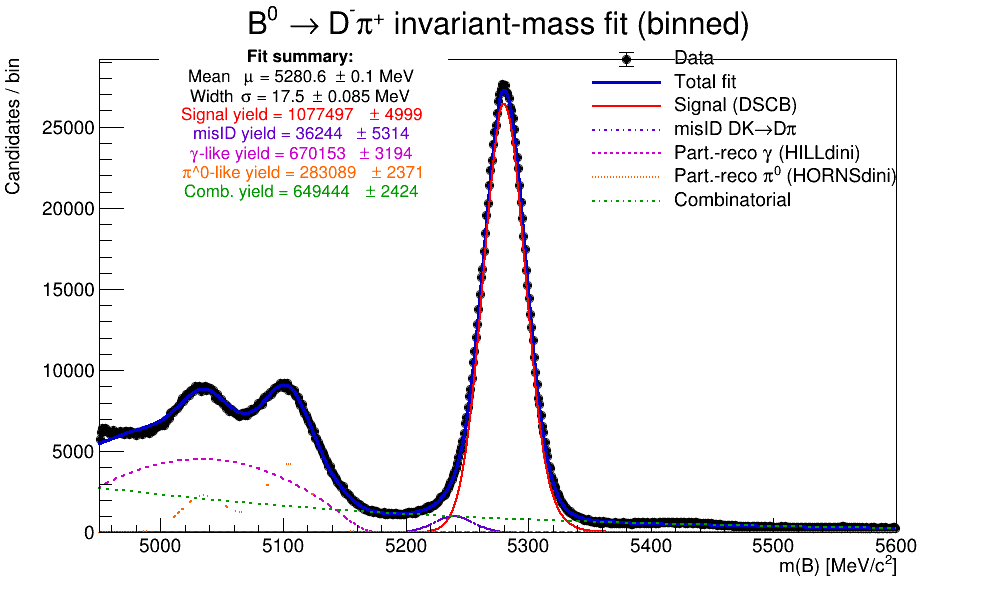


m)
1] INFO:NumericIntegration -- RooRealIntegral::init(BKG_pi_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
m)
PID1383843/RooRealMPFE::nll_pdf_dh_16dfb090_MPFE7[ arg=nll_pdf_dh_GOF7 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,c0,c1,c2,dHb,dMis,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig,sig_mis) ]

PID1383843/RooRealMPFE::nll_pdf_dh_16dfb090_MPFE7[ arg=nll_pdf_dh_GOF7 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,c0,c1,c2,dHb,dMis,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig,sig_mis) ]

(m)
NumericIntegrationRooRombergIntegrator --  to calculate IntRooRealIntegral::init((BKG_pi_Int[m]) using numeric integrator mRooRombergIntegrator) to calculate Int
(m)
 -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
PID1383994/RooRealMPFE::nll_pdf_dh_16dfb090_MPFE3[ arg=nll_pdf_dh_GOF3 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,c0,c1,c2,dHb,dMis,dR

Info in <TCanvas::Print>: png file /tmp/fit_1762773837.png has been created



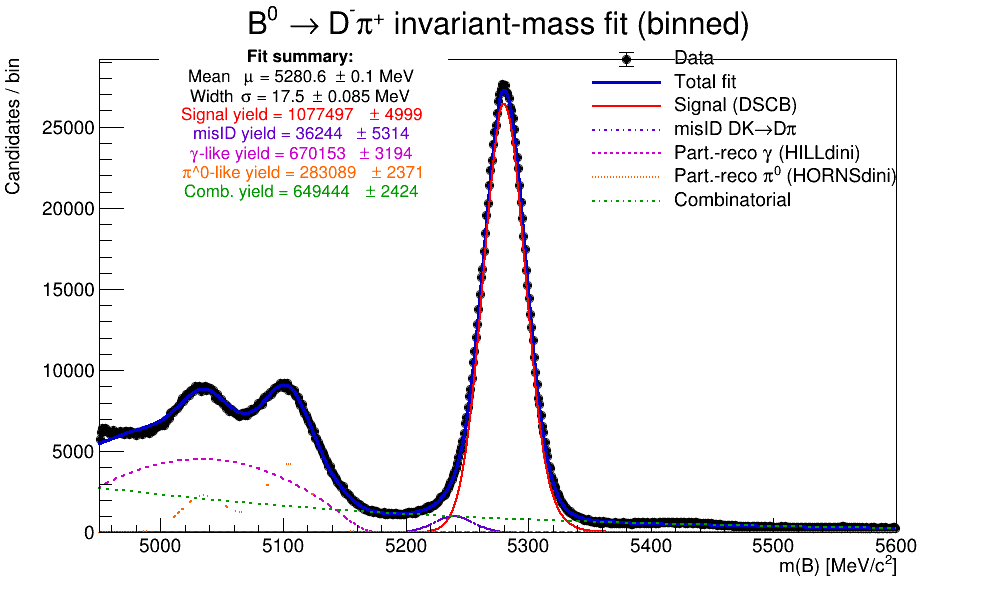

In [21]:
USE_SUBSET = False
SUBSET_N   = 300_000

# the 24c4 files need the lumi run selection
USE_S24C4_RUNS = True

NBINS      = 600            # finer binning for ~16 MeV core width
COMB_MODEL = "cheby"        # "cheby" or "expo"

D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MAX = 0.0     # pion-like bachelor
M_PI, M_K = 139.57039, 493.677
mmin, mmax = 4950., 5600.

# s24c4 run ranges, from the scan above
#   block7, magnet down: 307589 - 308098
#   block8, magnet up:   308104 - 308540
RUN_UP_MIN,   RUN_UP_MAX   = 308104, 308540
RUN_DOWN_MIN, RUN_DOWN_MAX = 307589, 308098

# XG cut
XG_CUT    = 0.5
XG_BRANCH = "BDTGResponse_XGB_1"

# build the Dπ sample
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
    "lab1_PIDK",
    "runNumber",          # used for lumi selection
    XG_BRANCH,
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build] applying Bd->Dπ cuts, "
      f"{'WITH' if USE_S24C4_RUNS else 'WITHOUT'} s24c4 lumi, "
      f"XG > {XG_CUT:.3f}, and skimming...")

all_runs = []

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]
    pidk = arrays["lab1_PIDK"]
    runs = arrays["runNumber"]
    xg   = arrays[XG_BRANCH]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
        np.isfinite(mD) & np.isfinite(pidk) &
        np.isfinite(runs) & np.isfinite(xg)
    )

    mB   = mB[finite]
    bchi = bchi[finite]
    dchi = dchi[finite]
    mD   = mD[finite]
    pidk = pidk[finite]
    runs = runs[finite]
    xg   = xg[finite]

    all_runs.append(runs)

    # lumi selection
    if USE_S24C4_RUNS:
        run_sel = (
            ((runs >= RUN_UP_MIN)   & (runs <= RUN_UP_MAX)) |
            ((runs >= RUN_DOWN_MIN) & (runs <= RUN_DOWN_MAX))
        )
    else:
        run_sel = np.ones_like(runs, dtype=bool)

    sel = (
        run_sel &
        (xg > XG_CUT) &
        (pidk < BACHELOR_PIDK_MAX) &
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

if all_runs:
    rr = np.concatenate(all_runs)
    print(f"[runs] runNumber range (after basic finite): {rr.min():.0f} – {rr.max():.0f}")

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError(
        "No events after cuts/subset.\n"
        "If USE_S24C4_RUNS=True, your files should contain runs "
        f"{RUN_DOWN_MIN}–{RUN_DOWN_MAX} and {RUN_UP_MIN}–{RUN_UP_MAX} "
        "in 'runNumber'. Check FILES and run ranges."
    )

# binned dataset
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# sign of the combinatorial slope, seeded from a regression at low mass
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]  # slope sign
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("h","h", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dh","binned Dpi", ROOT.RooArgList(m), dhist)

# seeds for the mean and width
focus = vals[(vals>5230)&(vals<5330)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5230,5330))
    edges = np.linspace(5230,5330,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# physics model
mu  = ROOT.RooRealVar("mu","mean", mu0, mu0-30., mu0+30.)
sig = ROOT.RooRealVar("sig","sigma", sig0, 8., 30.)

# signal, a double-sided Crystal Ball
aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# misidentified DK -> Dπ
dMis   = ROOT.RooRealVar("dMis","DK->Dpi shift",45,35,55)
mu_mis = ROOT.RooFormulaVar("mu_mis","@0-@1", ROOT.RooArgList(mu,dMis))
sig_mis= ROOT.RooRealVar("sig_mis","misID width",max(14.0,min(20.0,sig0+2.)),12,28)
MIS    = ROOT.RooGaussian("MIS","misID DK->Dpi", m, mu_mis, sig_mis)

# partially reconstructed γ (HILLdini) and π0 (HORNSdini)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# combinatorial
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# extended yields
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","signal yield", 0.15*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","misID yield",  0.01*Ntot, 0.0, 0.25*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",  0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",    0.01*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",  0.75*Ntot, 0.0, 2.0*Ntot)

# sideband constraints
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5450, 5600)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

mu_Ng,  sig_Ng  = 0.03*Ntot, max(1.0, 0.03*Ntot)
mu_Npi, sig_Npi = 0.01*Ntot, max(1.0, 0.01*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints.addOwned(gNg); constraints.addOwned(gNpi)

# prefit signal and combinatorial, tails frozen
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre","pre", ROOT.RooArgList(SIG,BKG_comb),
                         ROOT.RooArgList(Nsig,Ncomb))
print("\n[prefit] signal+comb (tails frozen)...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# full fit
pdf = ROOT.RooAddPdf("pdf","Dpi model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

print("\n[fit] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")

frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_{int(time.time())}","DpiFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                 "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",            "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal (DSCB)",               "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID DK#rightarrowD#pi",     "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",               "l")
leg.Draw()

box = ROOT.TPaveText(0.16, 0.66, 0.45, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"Signal yield = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"misID yield = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like yield = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like yield = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. yield = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved plot to {tmp_png}")


In [22]:
print(f"[build] kept {vals.size} events after all cuts")
print(f"[build] hist integral = {int(Ntot)}")

# which runs survive
rr = np.concatenate(all_runs)
print(f"[runs] min runNumber in file = {rr.min():.0f}")
print(f"[runs] max runNumber in file = {rr.max():.0f}")

# events passing the lumi selection
if USE_S24C4_RUNS:
    lumi_mask = (
        ((rr >= RUN_UP_MIN)   & (rr <= RUN_UP_MAX)) |
        ((rr >= RUN_DOWN_MIN) & (rr <= RUN_DOWN_MAX))
    )
    print(f"[runs] fraction of events inside lumi window = {lumi_mask.mean():.3f}")


[build] kept 2716691 events after all cuts
[build] hist integral = 2716691
[runs] min runNumber in file = 307589
[runs] max runNumber in file = 308540
[runs] fraction of events inside lumi window = 1.000



## Stacked components

The same fit with the components filled cumulatively instead of drawn as separate curves.


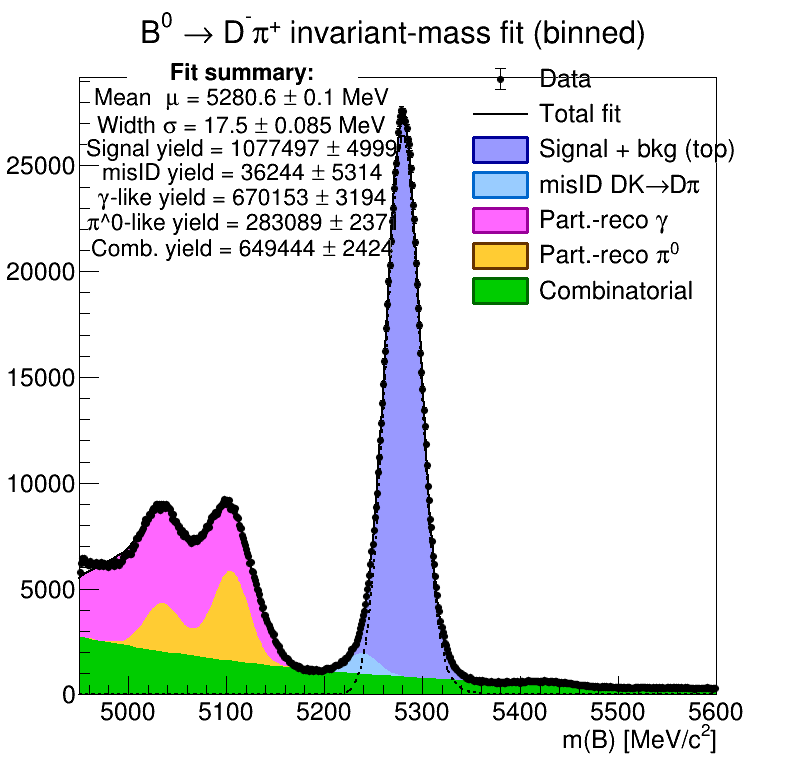



[26 RooFit INFO/Eval messages suppressed for readability]


Info in <TCanvas::Print>: png file /tmp/fit_1762774883.png has been created



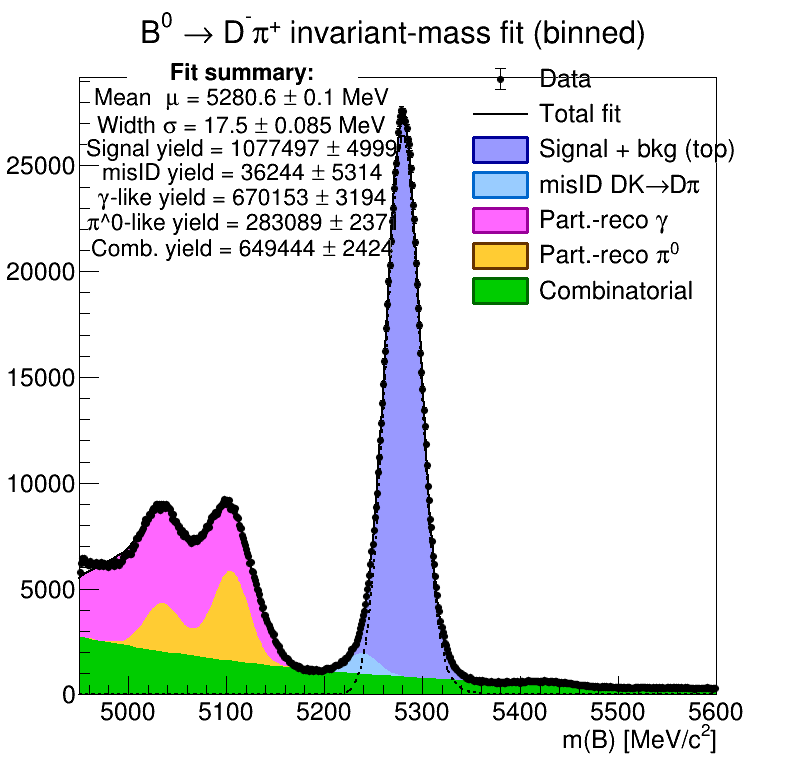

In [25]:
frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} invariant-mass fit (binned)"))

# data points
dh.plotOn(
    frame,
    RF.Name("data"),
    RF.MarkerStyle(20),
    RF.MarkerSize(0.8),
    RF.LineColor(ROOT.kBlack)
)

# combinatorial only
pdf.plotOn(
    frame,
    RF.Components("BKG_comb"),
    RF.Name("comb_stack"),
    RF.FillColor(ROOT.kGreen+1),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kGreen+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# plus π0-like
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi"),
    RF.Name("pi0_stack"),
    RF.FillColor(ROOT.kOrange-2),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kOrange+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# plus γ-like
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi,BKG_g"),
    RF.Name("gamma_stack"),
    RF.FillColor(ROOT.kMagenta-7),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kMagenta+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# plus misID
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi,BKG_g,MIS"),
    RF.Name("mis_stack"),
    RF.FillColor(ROOT.kAzure-9),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kAzure+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# full model, signal included
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi,BKG_g,MIS,SIG"),
    RF.Name("sig_stack"),
    RF.FillColor(ROOT.kBlue-9),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kBlue+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

pdf.plotOn(
    frame,
    RF.Name("total"),
    RF.LineColor(ROOT.kBlack),
    RF.LineWidth(2)
)

# signal-only curve
pdf.plotOn(
    frame,
    RF.Components("SIG"),
    RF.Name("sig_line"),
    RF.LineColor(ROOT.kBlack),
    RF.LineStyle(ROOT.kDashed),
    RF.LineWidth(2)
)

c = ROOT.TCanvas(f"c_{int(time.time())}","DpiFit",800,800)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

# legend entries refer to the stacked fills
leg = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),      "Data",                 "pe")
leg.AddEntry(frame.findObject("total"),     "Total fit",            "l")
leg.AddEntry(frame.findObject("sig_stack"), "Signal + bkg (top)",   "f")
leg.AddEntry(frame.findObject("mis_stack"), "misID DK#rightarrowD#pi", "f")
leg.AddEntry(frame.findObject("gamma_stack"),"Part.-reco #gamma",   "f")
leg.AddEntry(frame.findObject("pi0_stack"), "Part.-reco #pi^{0}",   "f")
leg.AddEntry(frame.findObject("comb_stack"),"Combinatorial",        "f")
leg.Draw()

box = ROOT.TPaveText(0.16, 0.66, 0.45, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"Signal yield = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kBlack)
t = box.AddText(f"misID yield = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kBlack)
t = box.AddText(f"#gamma-like yield = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kBlack)
t = box.AddText(f"#pi^{0}-like yield = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kBlack)
t = box.AddText(f"Comb. yield = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kBlack)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved plot to {tmp_png}")
